# 01 — Measurements by Water Type and Decade

Produces **Figure 7**: estimated number of measurements by water category and decade for the continental US, for all pages with a date associated.

Requires `data/analysis/processed_metadata.parquet` (output of `00_data_prep.ipynb`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
import sys
sys.path.insert(0, str(Path('.')))   # so water_palette imports cleanly
from water_palette import CATEGORY_ORDER, get_color_for

root         = Path('../..')
parquet_path = root / 'data/analysis/processed_metadata.parquet'
figures_path = root / 'manuscript/figures'
figures_path.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(parquet_path)
print(f'Loaded {len(df):,} rows')

Loaded 109,440 rows


## Filter and aggregate

Keep only primary water categories (exclude 'Not Water Related' and 'Other'). Group by decade × water type and sum estimated measurements.

In [2]:
WATER_CATEGORIES = [
    'Stream Discharge', 'Groundwater', 'Reservoir',
    'Irrigation', 'Springs', 'Precipitation', 'Water Quality'
]

df_water = df[
    df['water_type_clean'].isin(WATER_CATEGORIES) &
    df['decade_start'].notna() &
    df['n_measurements'].notna()
].copy()

print(f'{len(df_water):,} rows with water category, decade, and measurement count')

agg = (
    df_water.groupby(['decade_start', 'water_type_clean'])['n_measurements']
    .sum()
    .reset_index()
)

# Pivot: rows = decades, columns = water types
pivot = agg.pivot(index='decade_start', columns='water_type_clean', values='n_measurements').fillna(0)
# Reorder columns by canonical category order (those present)
cols_ordered = [c for c in CATEGORY_ORDER if c in pivot.columns]
pivot = pivot[cols_ordered]

print(f'\nTotal estimated measurements: {pivot.values.sum():,.0f}')
print(pivot.astype(int).to_string())

85,659 rows with water category, decade, and measurement count

Total estimated measurements: 3,175,477
water_type_clean  Stream Discharge  Groundwater  Precipitation  Irrigation  Reservoir  Springs  Water Quality
decade_start                                                                                                 
1810                             0            0              0          12          0        0              0
1820                           102            0              0          27          0        0              0
1830                            17            0              0           0          0        0              0
1840                           108            0            457           0          3        0              0
1850                           305           13            973           6          0        0              0
1860                          4197          131            785          50         20       84              0
1870            

## Figure 7 — Measurements by water type × decade

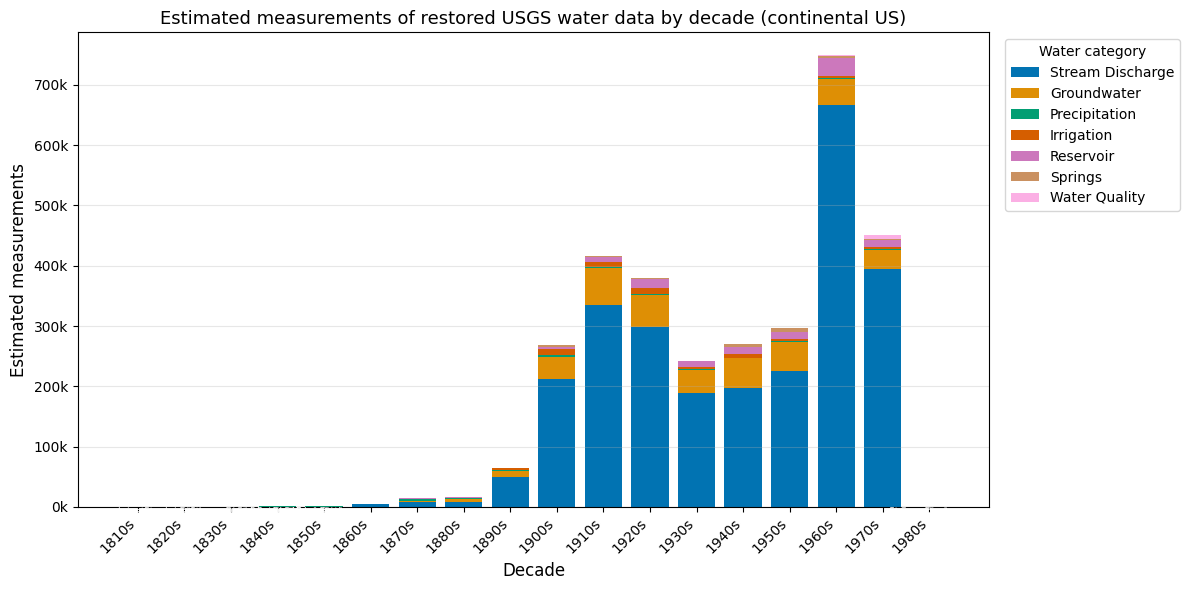

Saved measurements_by_type_decade.png


In [3]:
fig, ax = plt.subplots(figsize=(12, 6))

decades = pivot.index.astype(int)
x = np.arange(len(decades))
bar_width = 0.8
bottom = np.zeros(len(decades))

for wtype in pivot.columns:
    vals = pivot[wtype].values
    color = get_color_for(wtype)
    bars = ax.bar(x, vals, bar_width, bottom=bottom, color=color, label=wtype)

    # Annotate tiny bars in early decades with text
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 0 and pivot.values[i].sum() < 5000:
            ax.text(x[i], b + v / 2, f'{int(v):,}\n{wtype}',
                    ha='center', va='center', fontsize=6.5, color='white')
    bottom = bottom + vals

ax.set_xticks(x)
ax.set_xticklabels([f'{int(d)}s' for d in decades], rotation=45, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e6:.1f}M' if v >= 1e6 else f'{v/1e3:.0f}k'))
ax.set_xlabel('Decade', fontsize=12)
ax.set_ylabel('Estimated measurements', fontsize=12)
ax.set_title('Estimated measurements of restored USGS water data by decade (continental US)', fontsize=13)
ax.legend(title='Water category', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(figures_path / 'measurements_by_type_decade.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved measurements_by_type_decade.png')